Loading data from: /sfs/gpfs/tardis/home/upw4ys/Documents/floodnet_work/Data_Files/rain_influenced_gages.parquet
✅ Created df_clean with 52145 rows.

📊 Time Gaps Between Storms (Negative means overlap):
count                          79
mean       1 days 21:28:58.812025
std        6 days 14:21:23.361827
min      -2 days +18:20:54.004000
25%      -1 days +13:56:22.783000
50%      -1 days +15:46:14.582000
75%        1 days 04:28:28.504500
max       38 days 14:40:52.758000
Name: gap_to_prev, dtype: object

Number of perfectly overlapping/nested storms: 51


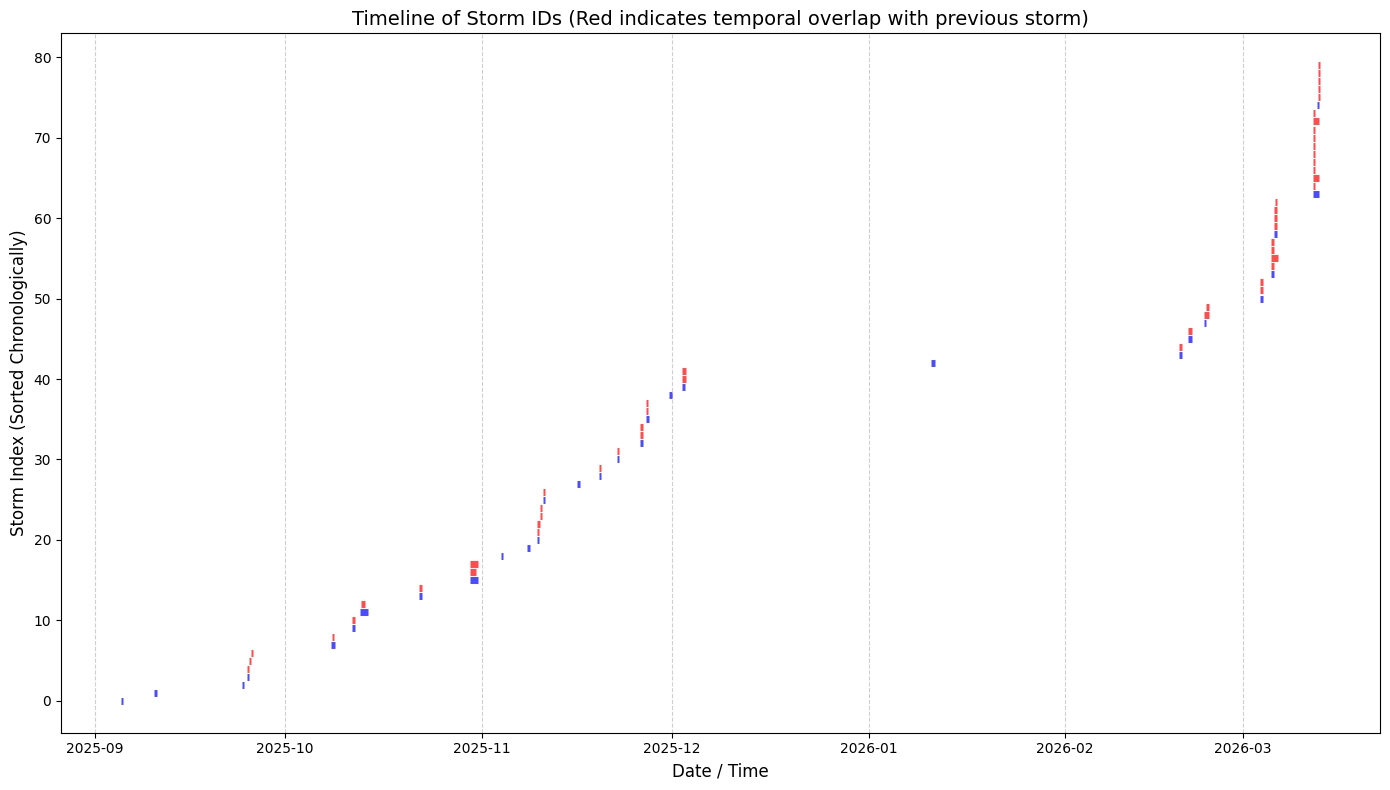

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# ── 1. Configuration & Pathing (From your script) ────────────────────────────
# Configuration and Feature Selection
FEATURES = [
    'precip_1hr [inch]', 
    'precip_max_intensity [inch/hour]', 
    'temp_2m [degF]', 
    # 'soil_moisture_05cm [m^3/m^3]',  <-- REMOVE THIS
    'elevation [feet]'
]
TARGET = 'depth_inches'

# Navigate to Project Root and load data
current_location = Path.cwd().resolve()
if current_location.name in ["Finalized_Scripts", "Test_Scripts", "scripts"]:
    PROJECT_ROOT = current_location.parent
else:
    PROJECT_ROOT = current_location

file_path = PROJECT_ROOT / "Data_Files" / "rain_influenced_gages.parquet"

print(f"Loading data from: {file_path}")
df = pd.read_parquet(file_path)

# ── 2. Identify Storm Column ─────────────────────────────────────────────────
STORM_COL = None
for candidate in ['global_storm_id', 'storm_id', 'event_id', 'storm', 'event']:
    if candidate in df.columns:
        STORM_COL = candidate
        break

if STORM_COL is None:
    raise ValueError("Could not find a valid storm ID column in the dataset.")

# ── 3. Create df_clean ───────────────────────────────────────────────────────
META_CANDIDATES = ["deployment_id", "time", "timestamp", "datetime", "global_storm_id", "storm_start", "storm_end"]
META_COLS = [c for c in META_CANDIDATES if c in df.columns]

all_cols = list(dict.fromkeys(FEATURES + [TARGET, STORM_COL] + META_COLS))
df_clean = df[all_cols].dropna(
    subset=FEATURES + [TARGET, STORM_COL]
).copy()

df_clean[FEATURES + [TARGET]] = df_clean[FEATURES + [TARGET]].astype('float32')
print(f"✅ Created df_clean with {len(df_clean)} rows.")

# ── 4. Diagnostic: Storm Overlap & Gap Analysis ──────────────────────────────
# Extract just the unique storm timing metadata
storm_meta = df_clean[['global_storm_id', 'storm_start', 'storm_end']].drop_duplicates()
storm_meta = storm_meta.sort_values('storm_start').reset_index(drop=True)

# Convert to datetime if they aren't already
storm_meta['storm_start'] = pd.to_datetime(storm_meta['storm_start'])
storm_meta['storm_end'] = pd.to_datetime(storm_meta['storm_end'])

# Calculate the gap from the END of the previous storm to the START of the current one
storm_meta['prev_end'] = storm_meta['storm_end'].shift(1)
storm_meta['gap_to_prev'] = storm_meta['storm_start'] - storm_meta['prev_end']

print("\n📊 Time Gaps Between Storms (Negative means overlap):")
print(storm_meta['gap_to_prev'].describe())
print(f"\nNumber of perfectly overlapping/nested storms: {(storm_meta['gap_to_prev'] < pd.Timedelta(0)).sum()}")

# ── 5. Visualize the Timeline ────────────────────────────────────────────────
plt.figure(figsize=(14, 8))

for i, row in storm_meta.iterrows():
    # Color overlapping storms red, standalone storms blue
    color = 'red' if row['gap_to_prev'] < pd.Timedelta(hours=0) else 'blue'
    plt.hlines(y=i, xmin=row['storm_start'], xmax=row['storm_end'], 
               linewidth=5, color=color, alpha=0.7)

plt.xlabel('Date / Time', fontsize=12)
plt.ylabel('Storm Index (Sorted Chronologically)', fontsize=12)
plt.title('Timeline of Storm IDs (Red indicates temporal overlap with previous storm)', fontsize=14)
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [4]:
print(df[FEATURES + [TARGET]].isna().sum())

precip_1hr [inch]                     198
precip_max_intensity [inch/hour]      138
temp_2m [degF]                       2513
soil_moisture_05cm [m^3/m^3]        45776
elevation [feet]                        0
depth_inches                            0
dtype: int64
